## Another plotting 
### Input dynamic effect by cohort dataframe


In [110]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [122]:
import numpy as np
import matplotlib.pyplot as plt


def plot_event_study(
    df,
    x_col="new_event_time",
    y_col="effect",
    ci_low_col="ci_low",
    ci_high_col="ci_high",
    title="Event-study",
    xlabel="Event time",
    ylabel="Treatment Effect"
):

    # 排序
    df = df.sort_values(x_col)

    plt.figure(figsize=(9, 6))

    # confidence interval
    plt.fill_between(
        df[x_col],
        df[ci_low_col],
        df[ci_high_col],
        alpha=0.2
    )

    # line + point
    plt.plot(
        df[x_col],
        df[y_col],
        marker="o",
        linewidth=2
    )

    # reference lines
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    # =========================
    # xticks: every 2 integers
    # =========================
    xmin = int(df[x_col].min())
    xmax = int(df[x_col].max())

    plt.xticks(
        np.arange(
            xmin,
            xmax + 1,
            2
        )
    )

    # labels
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_event_study_by_cohort(
    df,
    cohort_col="cohort_month",
    x_col="new_event_time",
    y_col="coef",
    ci_low_col="ci_lower",
    ci_high_col="ci_upper"
):

    df = df.copy()

    # 建 cohort label
    df["cohort_label"] = pd.to_datetime(
        "2025-" + df[cohort_col].astype(str),
        format="%Y-%m"
    ).dt.strftime("%b %Y")

    # 每個 cohort 各畫一張
    for cohort, g in df.groupby("cohort_label"):

        g = g.sort_values(x_col)

        plt.figure(figsize=(8, 5))

        # confidence interval
        plt.fill_between(
            g[x_col],
            g[ci_low_col],
            g[ci_high_col],
            alpha=0.2
        )

        # line + points
        plt.plot(
            g[x_col],
            g[y_col],
            marker="o",
            linewidth=2
        )

        # reference lines
        plt.axhline(
            0,
            linestyle="--",
            linewidth=1.5
        )

        plt.axvline(
            0,
            linestyle="--",
            linewidth=1.5
        )

        # title
        plt.title(
            cohort,
            fontsize=14
        )

        plt.xlabel(
            "Event Time Relative to Tariff Exposure"
        )

        plt.ylabel(
            "Estimated Treatment Effect"
        )

        plt.tight_layout()


        # x 軸只顯示 2 的倍數
        xmin = int(df["new_event_time"].min())
        xmax = int(df["new_event_time"].max())

        plt.xticks(
            np.arange(
                2 * (xmin // 2),
                xmax + 1,
                2
            )
        )
        plt.show()

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_overall_dynamic_effect(
    df,
    event_time_col="new_event_time",
    coef_col="coef",
    ci_lower_col="ci_lower",
    ci_upper_col="ci_upper",
    weight_col="n_treated",
    min_event_time=None,
    figsize=(9, 6)
):

    df = df.copy()

    # =========================
    # numeric conversion
    # =========================
    numeric_cols = [
        event_time_col,
        coef_col,
        ci_lower_col,
        ci_upper_col,
        weight_col
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # remove missing event time
    df = df.dropna(
        subset=[event_time_col]
    )

    # filter
    if min_event_time is not None:
        df = df[
            df[event_time_col] >= min_event_time
        ]

    # =========================
    # weighted aggregation
    # =========================
    pooled = (
        df.groupby(event_time_col)
        .apply(
            lambda g: pd.Series({
                "coef": np.average(
                    g[coef_col],
                    weights=g[weight_col]
                ),

                "ci_lower": np.average(
                    g[ci_lower_col],
                    weights=g[weight_col]
                ),

                "ci_upper": np.average(
                    g[ci_upper_col],
                    weights=g[weight_col]
                ),

                "n_treated": g[weight_col].sum()
            })
        )
        .reset_index()
        .sort_values(event_time_col)
    )

    # =========================
    # plotting
    # =========================
    plt.figure(figsize=figsize)

    # CI
    plt.fill_between(
        pooled[event_time_col],
        pooled["ci_lower"],
        pooled["ci_upper"],
        alpha=0.2
    )

    # line
    plt.plot(
        pooled[event_time_col],
        pooled["coef"],
        marker="o",
        linewidth=2
    )

    # reference lines
    plt.axhline(
        0,
        linestyle="--",
        linewidth=2
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=2
    )

    # integer x ticks
    xmin = int(pooled[event_time_col].min())
    xmax = int(pooled[event_time_col].max())

    plt.xticks(
        np.arange(
            2 * (xmin // 2),
            xmax + 1,
            2
        )
    )

    plt.title(
        "Overall Dynamic Treatment Effect",
        fontsize=14
    )

    plt.xlabel(
        "Event Time Relative to Treatment"
    )

    plt.ylabel(
        "Estimated Treatment Effect"
    )

    plt.tight_layout()
    plt.show()

    return pooled

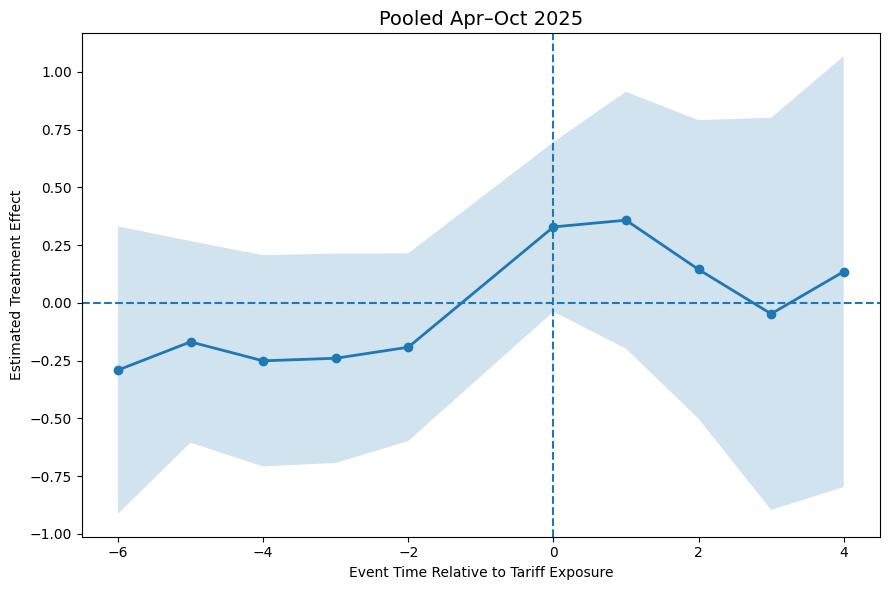

In [114]:
df = pd.read_csv("combine/low_dynamic_cohort_effect_reindexed_4-10.csv")
plot_event_study(
    df,
    title="Pooled Apr–Oct 2025",
    xlabel="Event Time Relative to Tariff Exposure",
    ylabel="Estimated Treatment Effect"
)

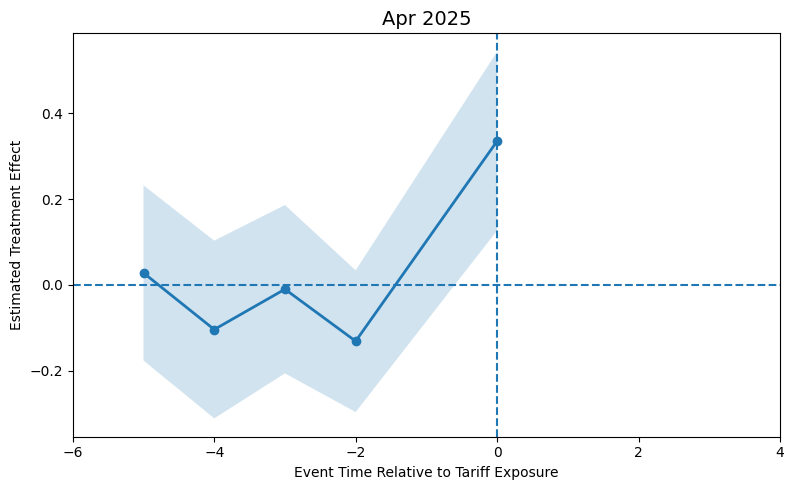

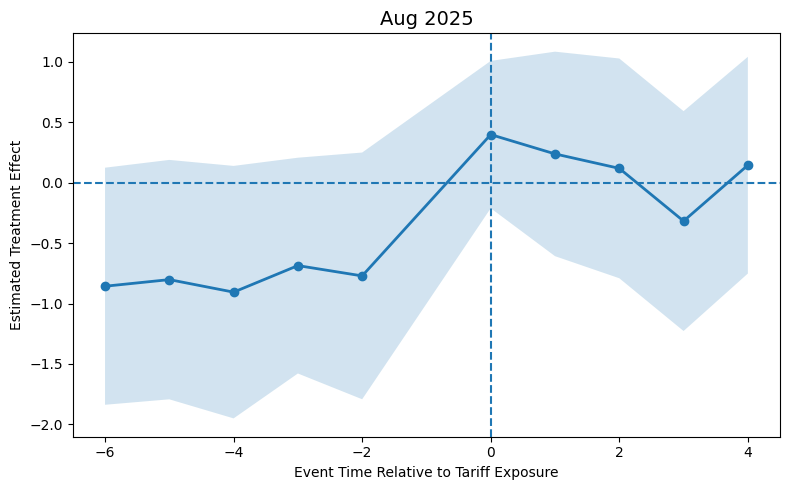

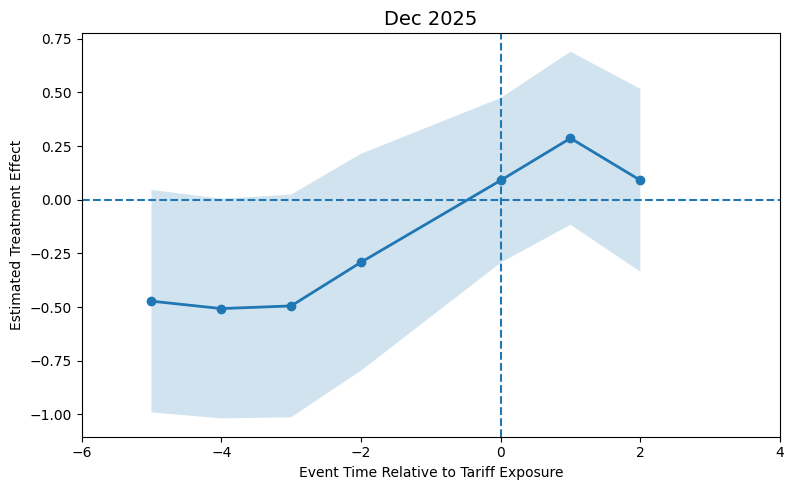

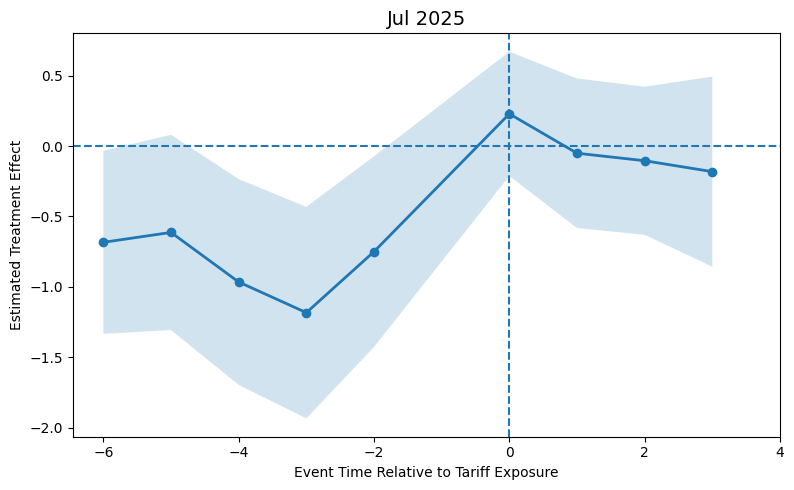

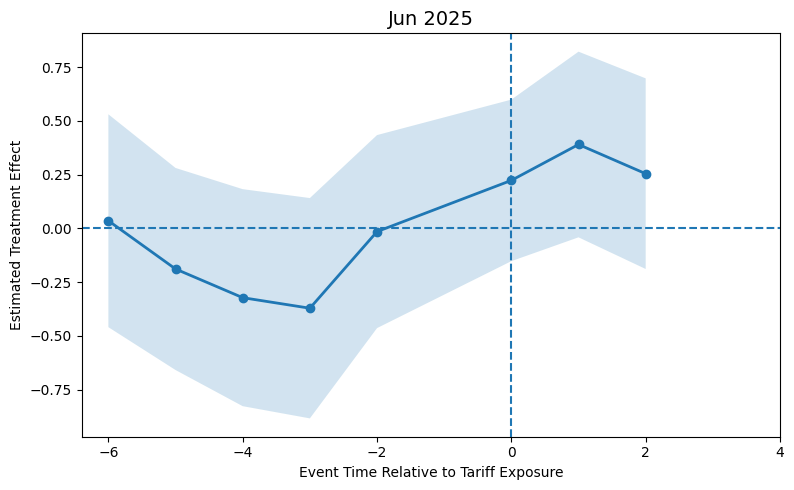

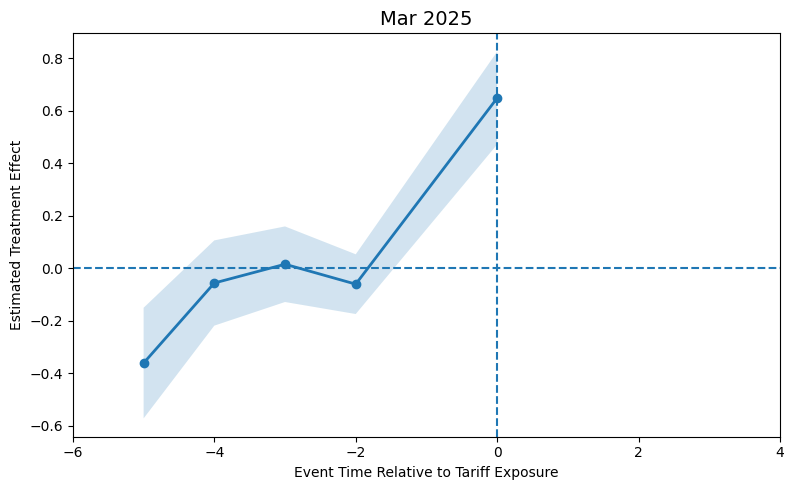

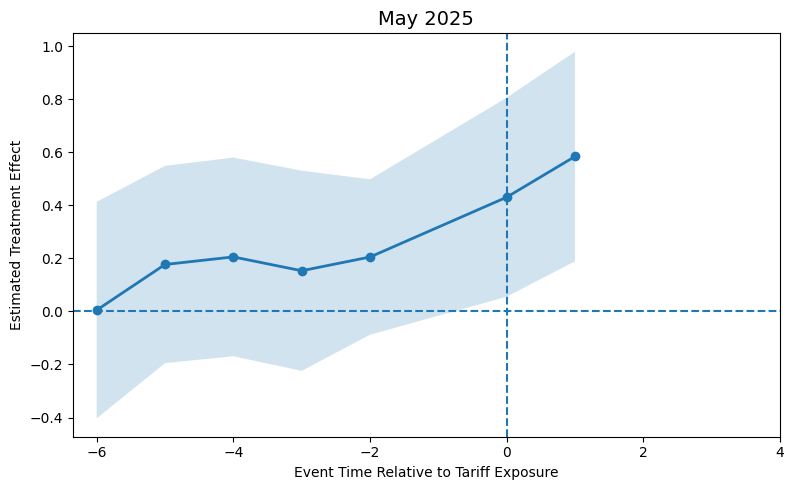

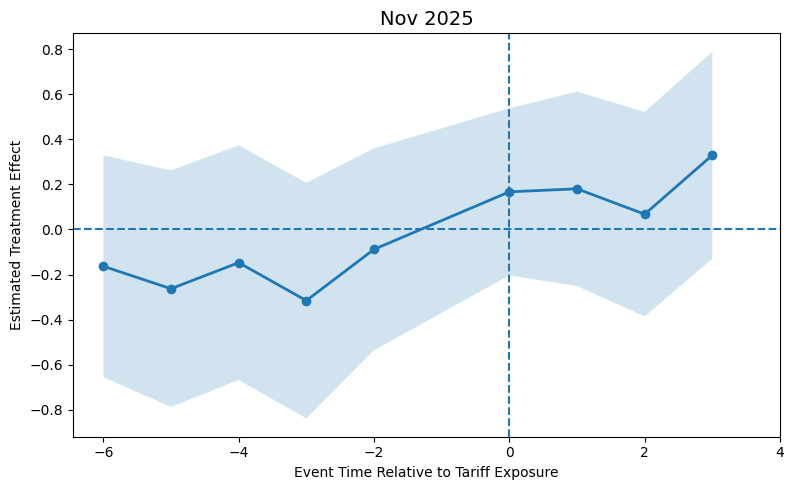

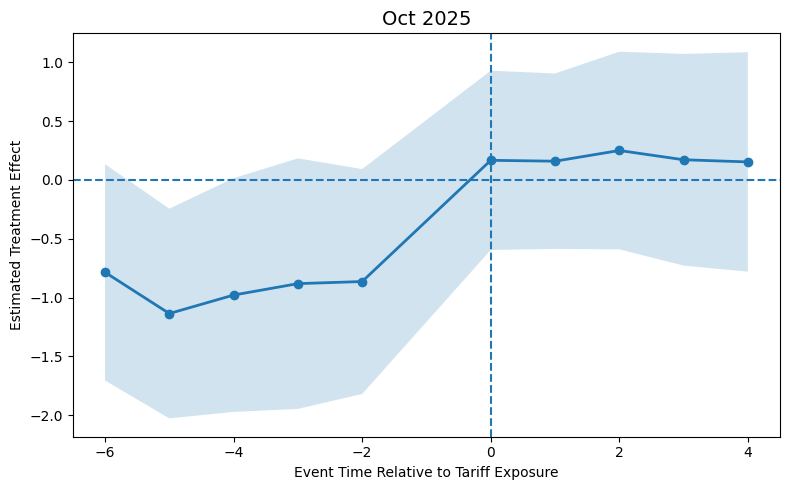

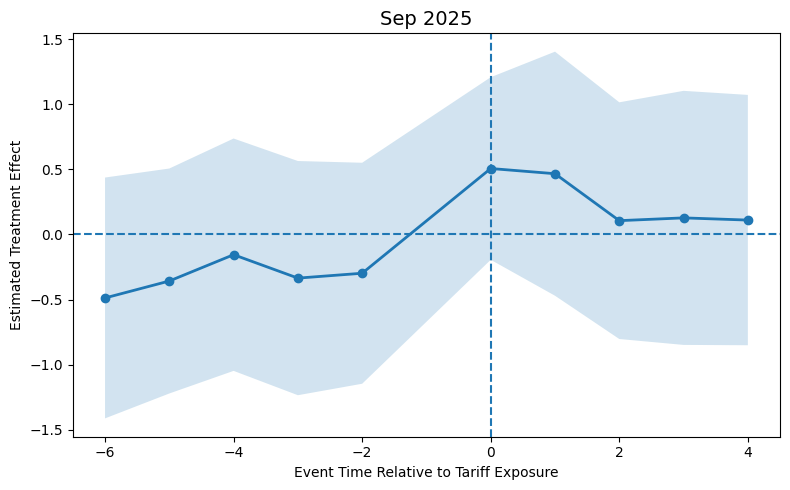

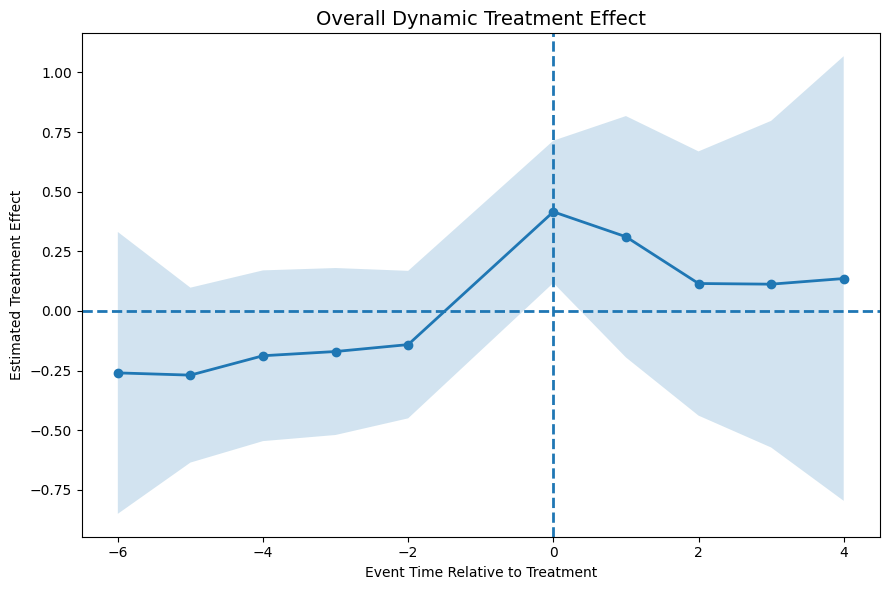

In [115]:
df = pd.read_csv("combine/low_dynamic_cohort_effect_reindexed.csv")
plot_event_study_by_cohort(
    df,
)

pooled_df = plot_overall_dynamic_effect(
    df,
    min_event_time=-12
)

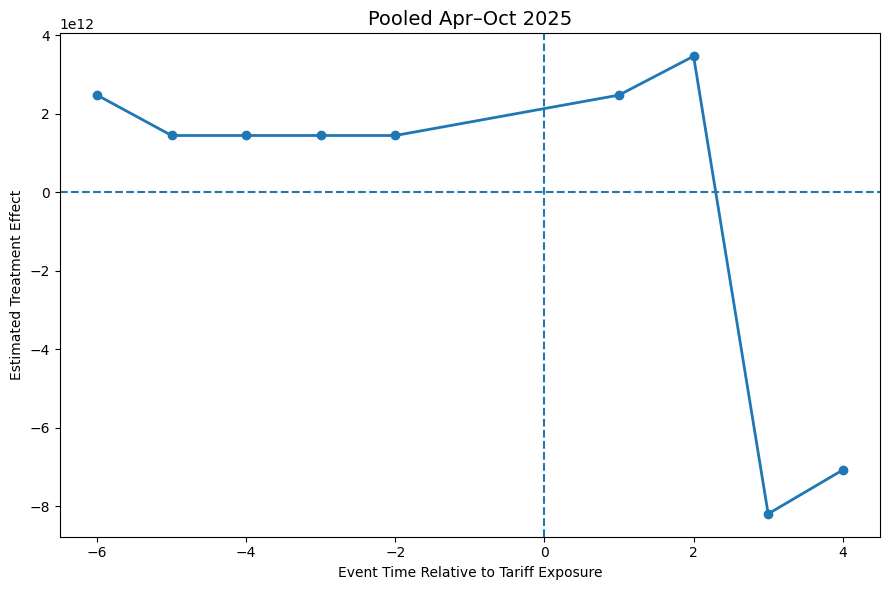

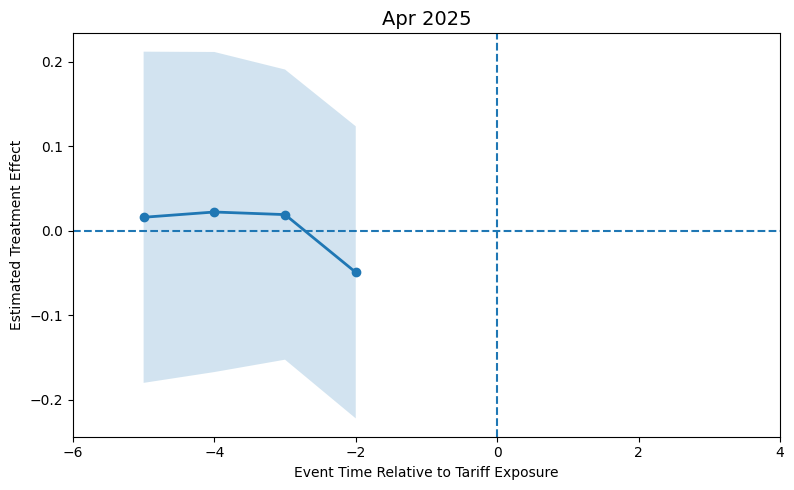

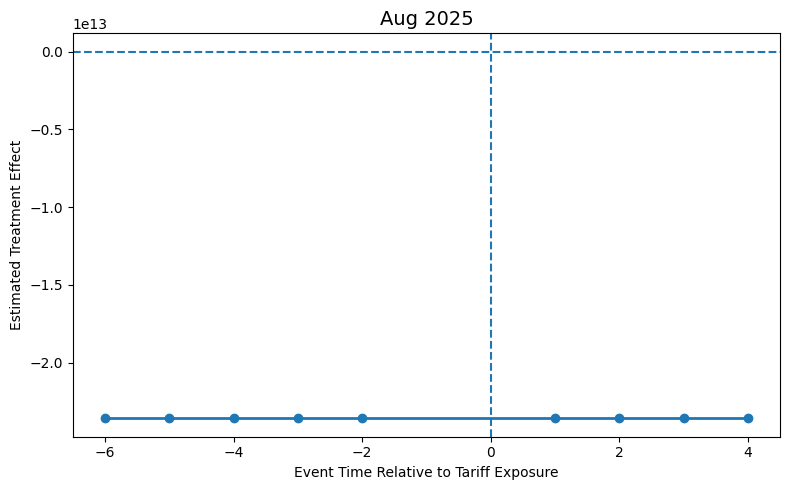

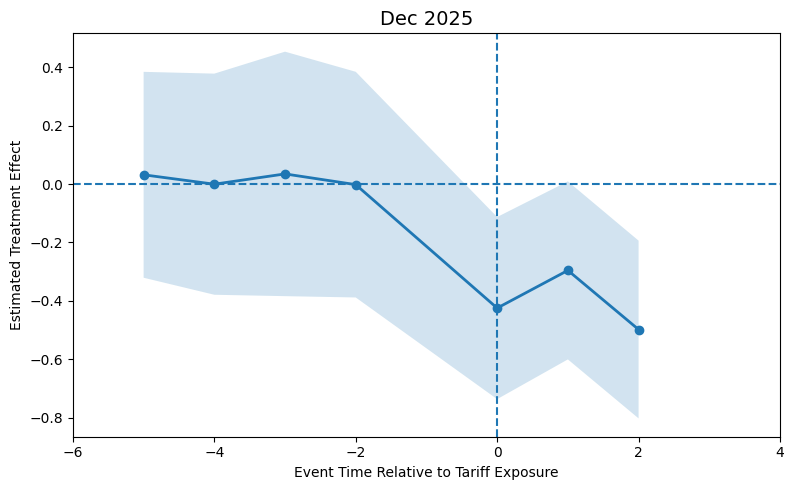

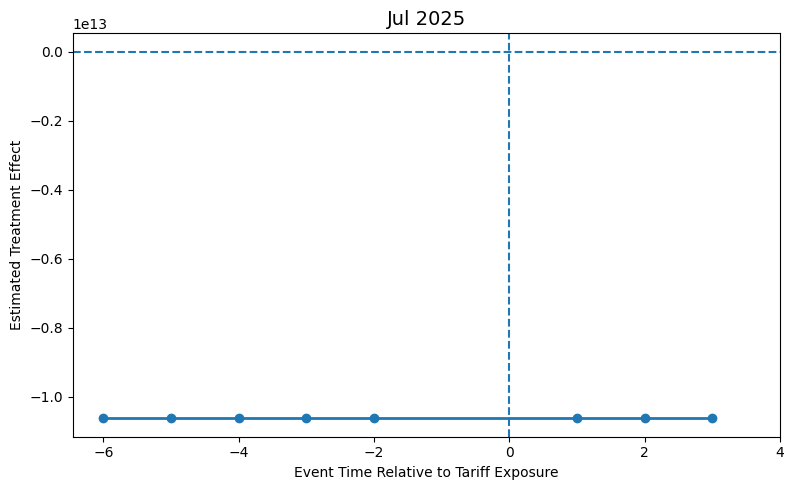

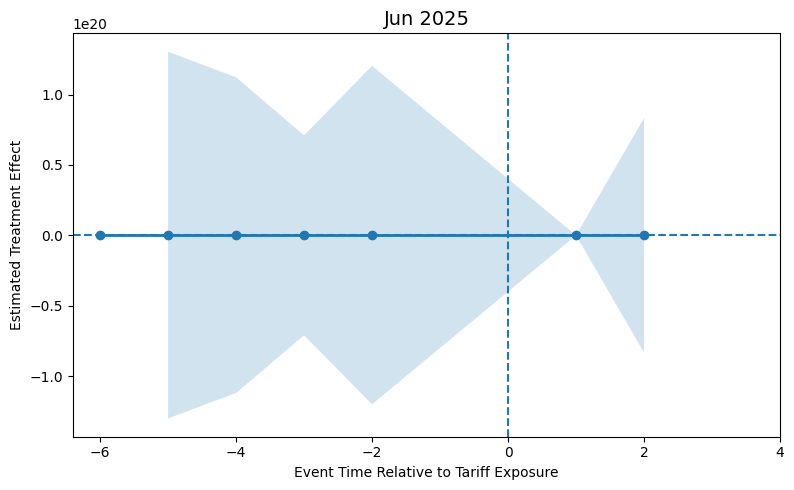

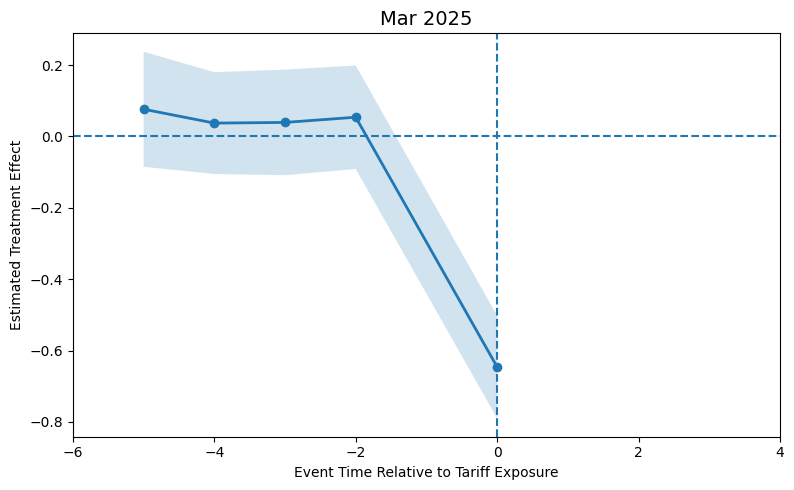

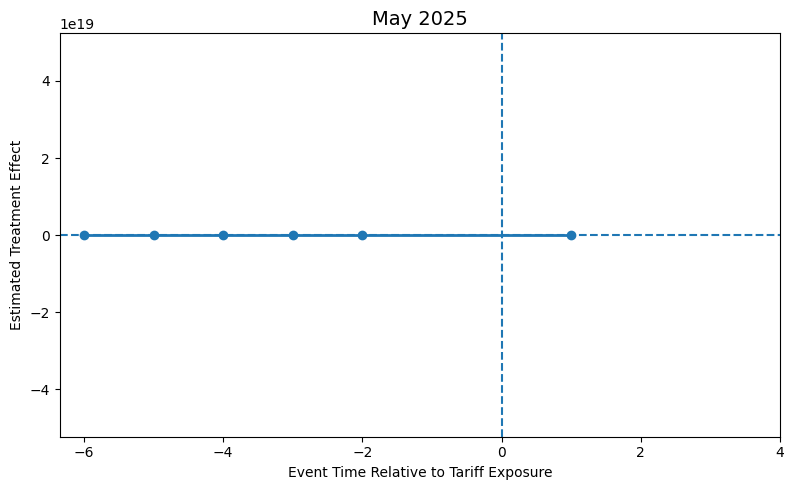

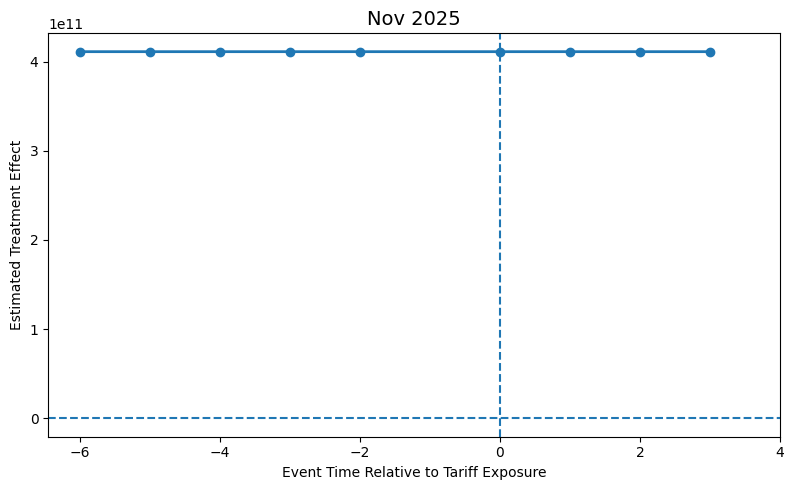

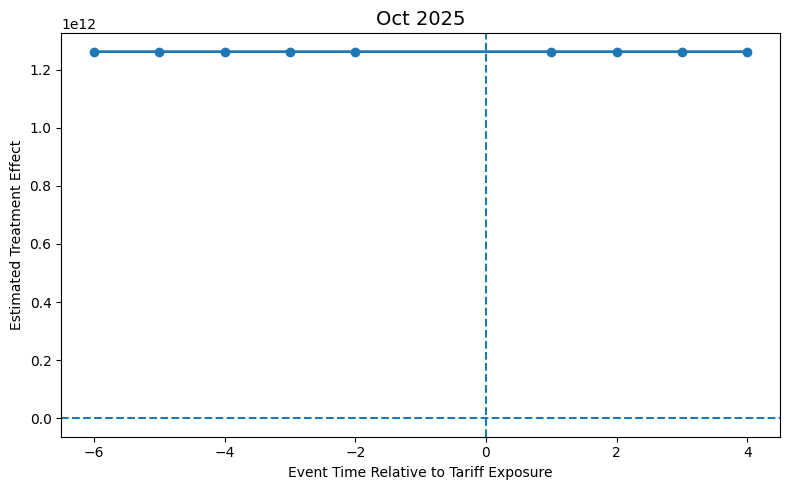

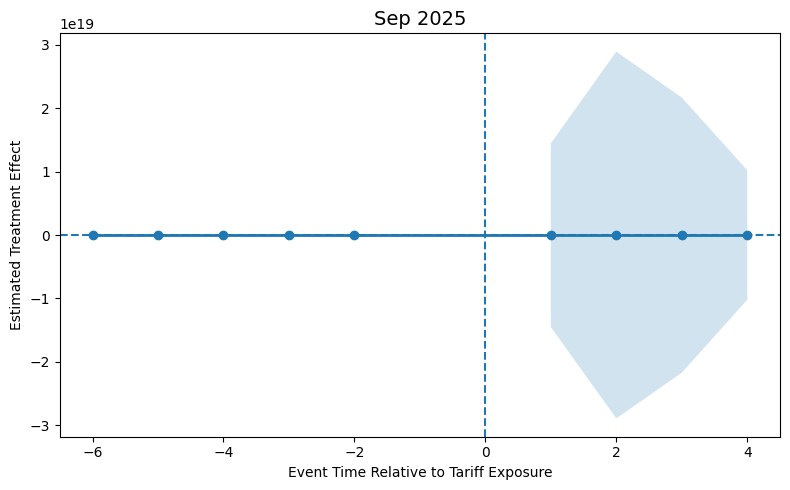

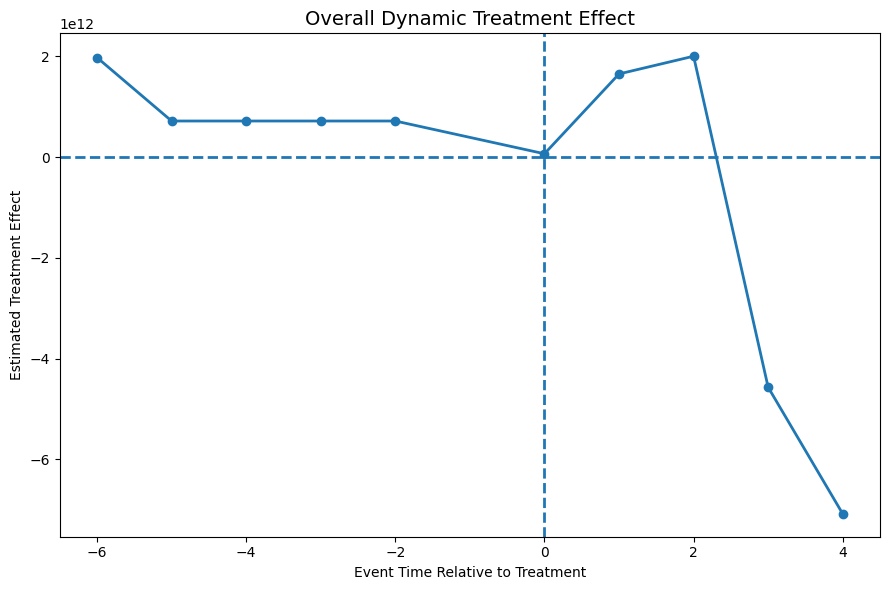

In [116]:
df = pd.read_csv("combine/high_dynamic_cohort_effect_reindexed_4-10.csv")
plot_event_study(
    df,
    title="Pooled Apr–Oct 2025",
    xlabel="Event Time Relative to Tariff Exposure",
    ylabel="Estimated Treatment Effect"
)

df = pd.read_csv("combine/high_dynamic_cohort_effect_reindexed.csv")
plot_event_study_by_cohort(
    df,
)
pooled_df = plot_overall_dynamic_effect(
    df,
    min_event_time=-12
)

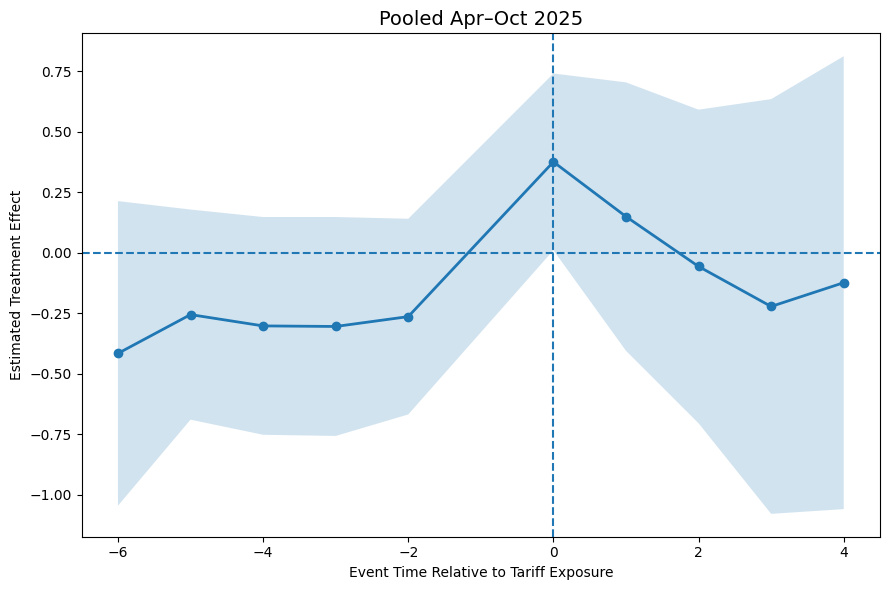

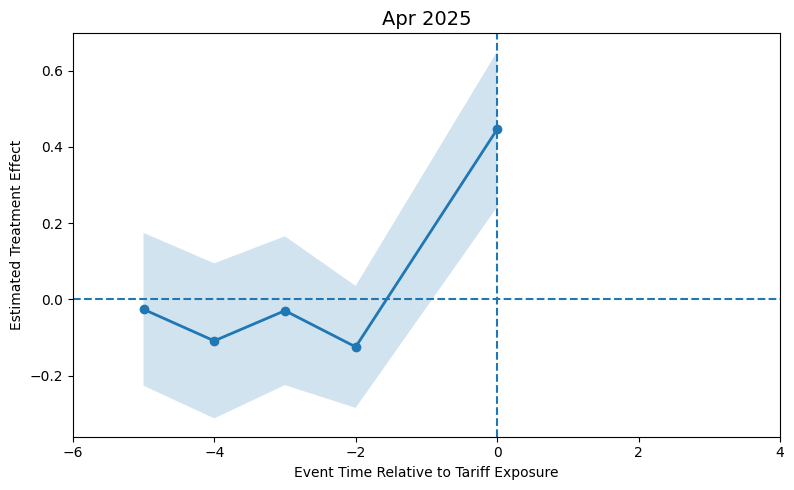

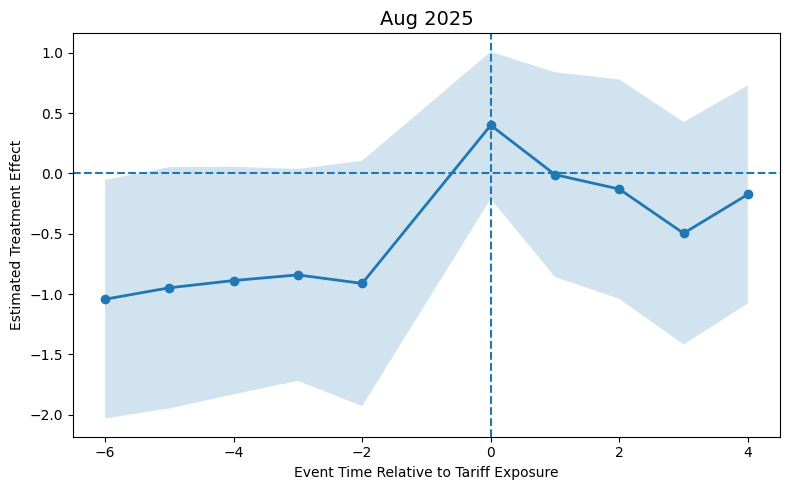

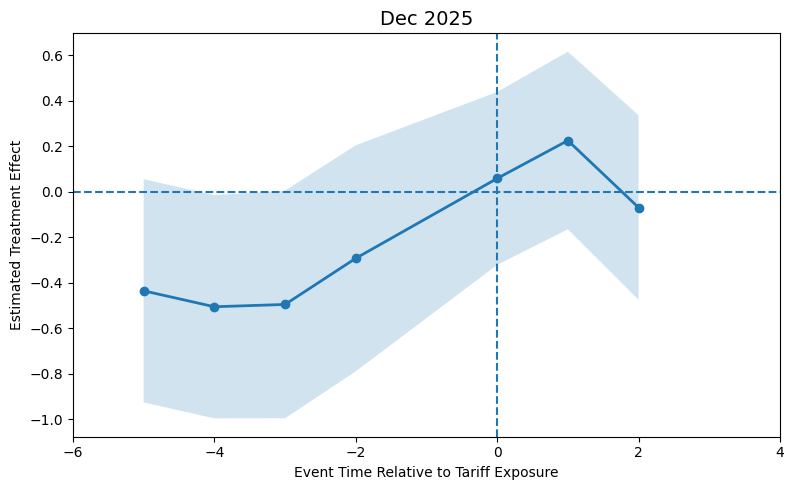

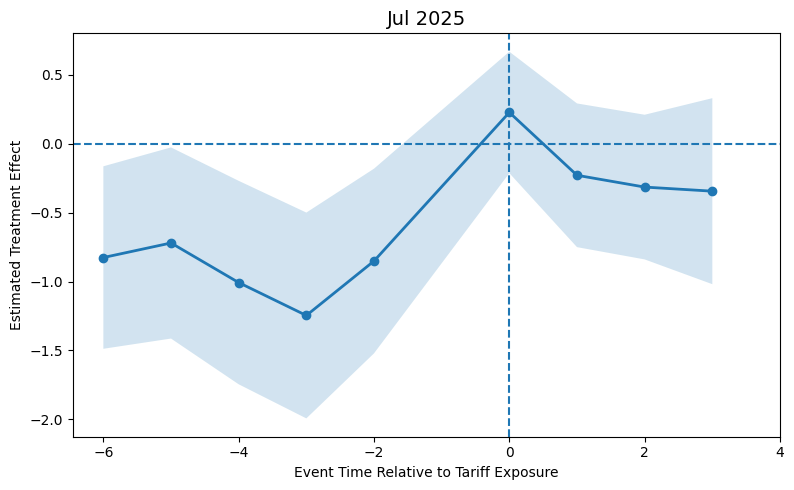

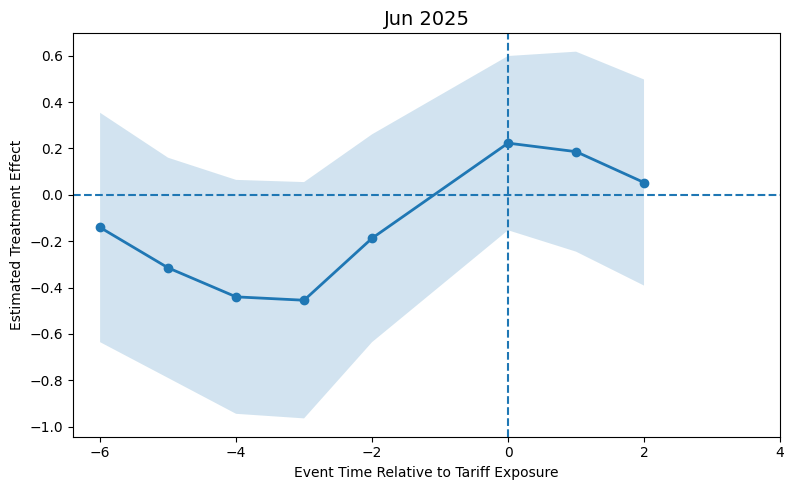

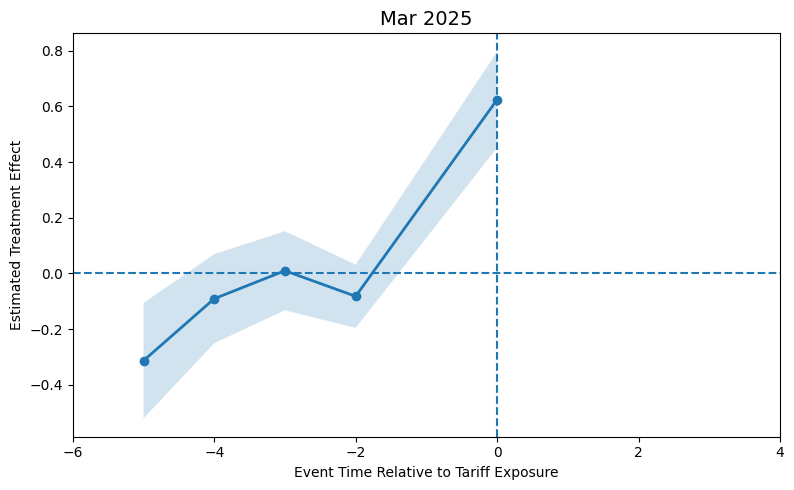

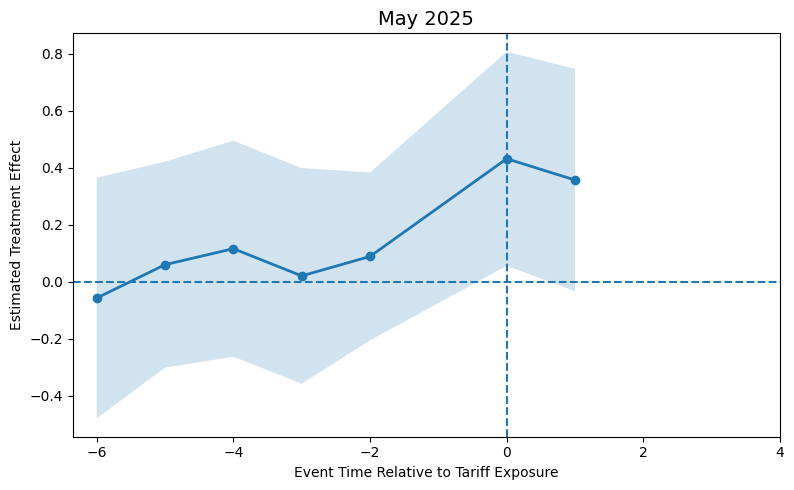

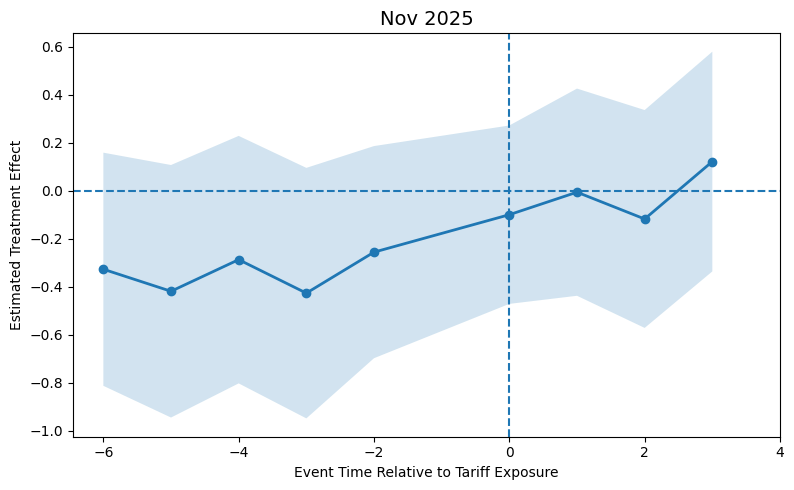

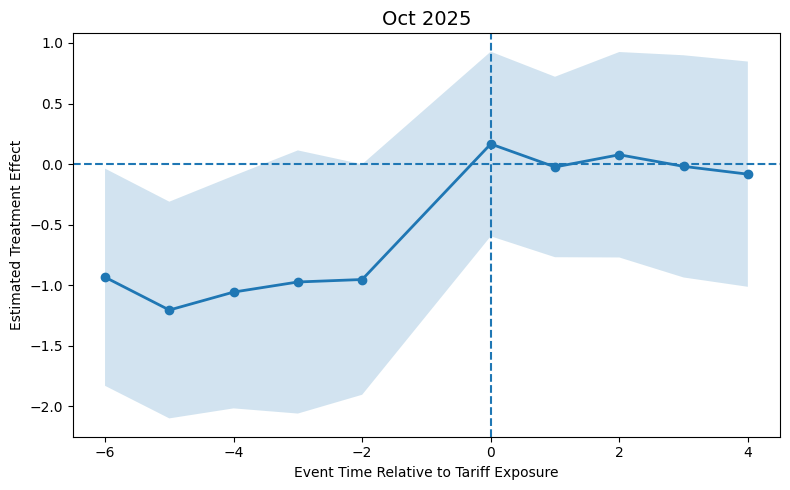

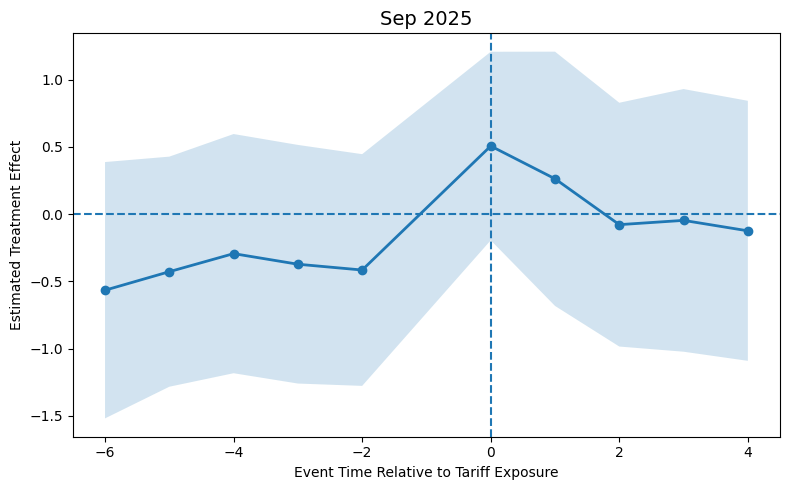

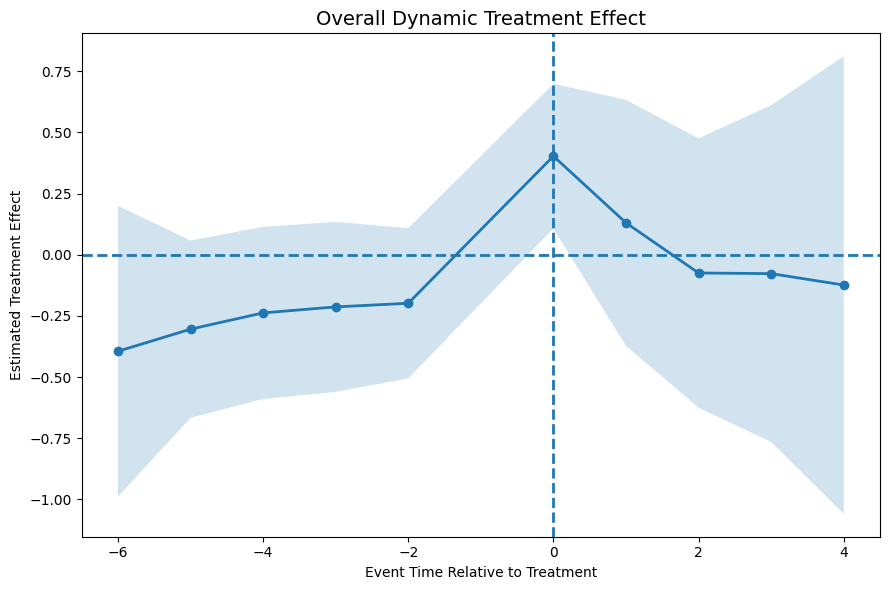

In [119]:
df = pd.read_csv("combine/all_dynamic_reindexed_4-10.csv")
plot_event_study(
    df,
    title="Pooled Apr–Oct 2025",
    xlabel="Event Time Relative to Tariff Exposure",
    ylabel="Estimated Treatment Effect"
)

df = pd.read_csv("combine/all_dynamic_reindexed.csv")
plot_event_study_by_cohort(
    df,
)

pooled_df = plot_overall_dynamic_effect(
    df,
    min_event_time=-12
)

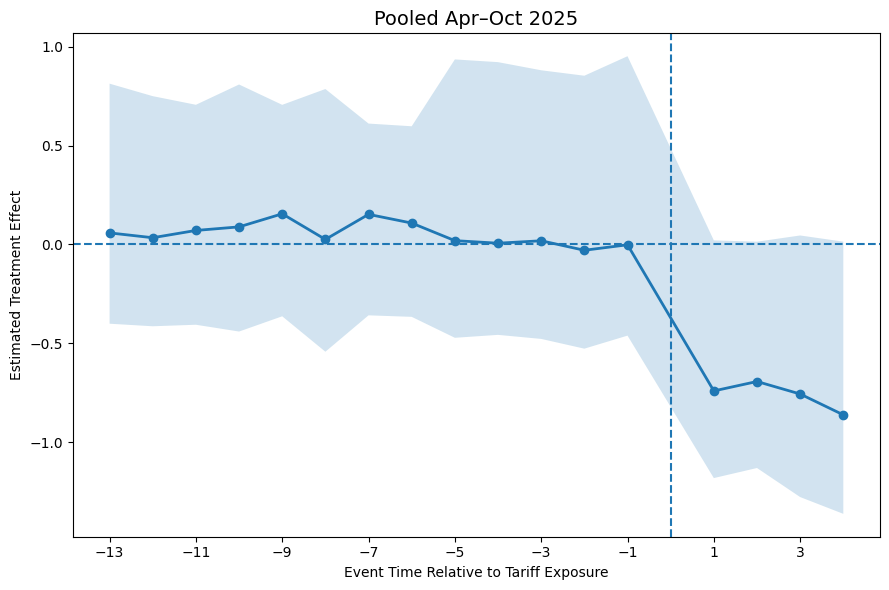

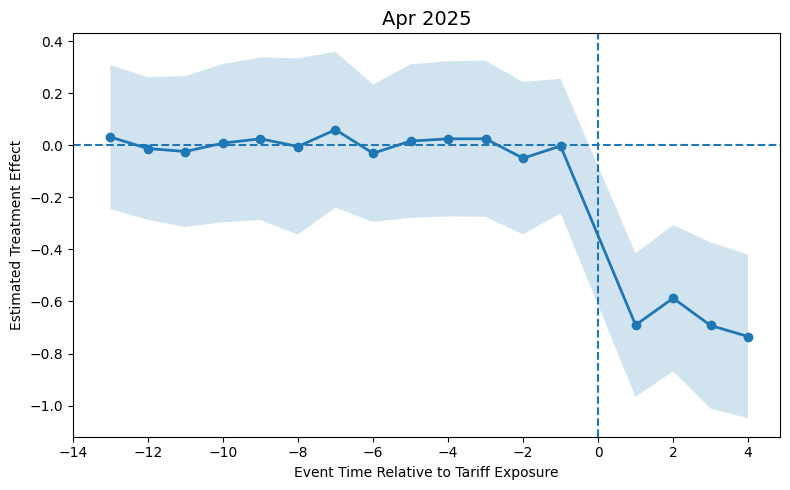

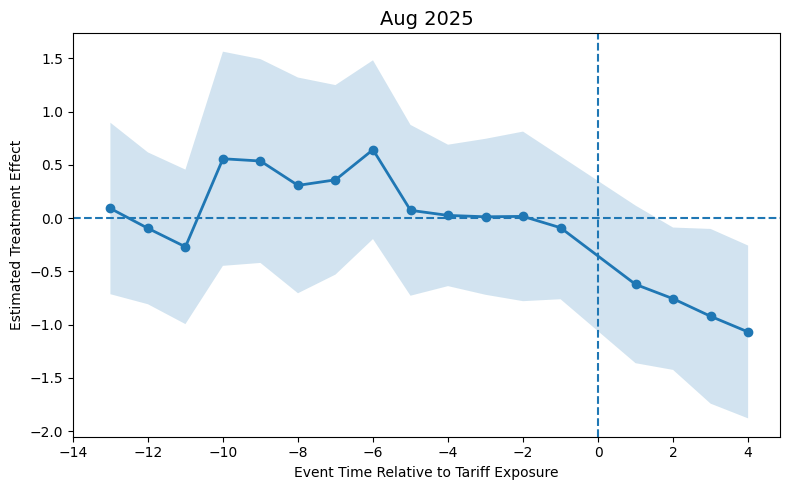

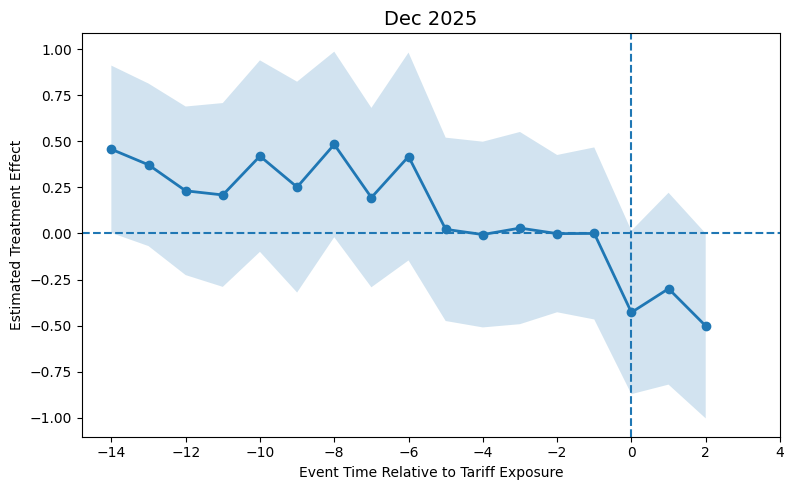

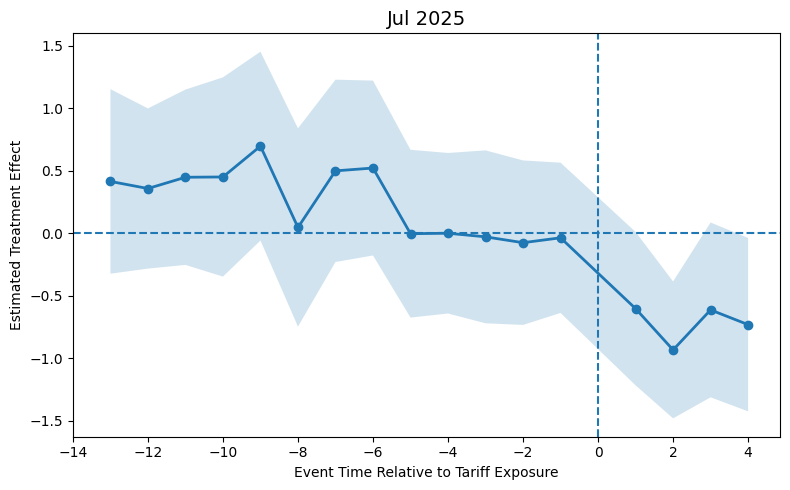

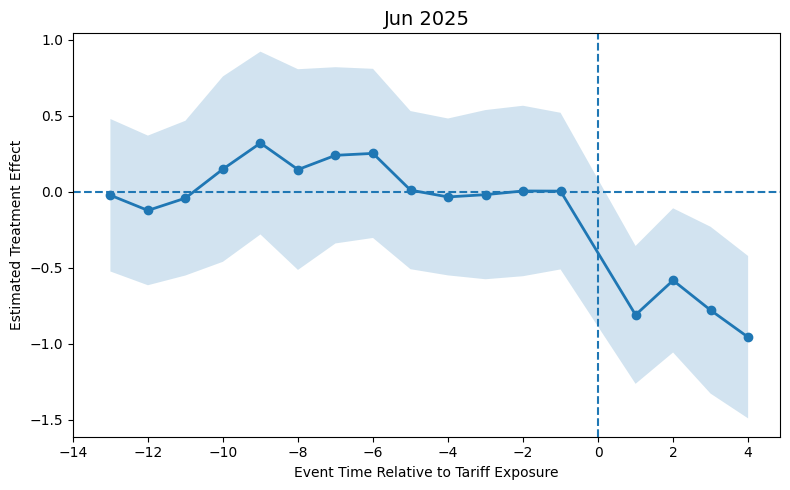

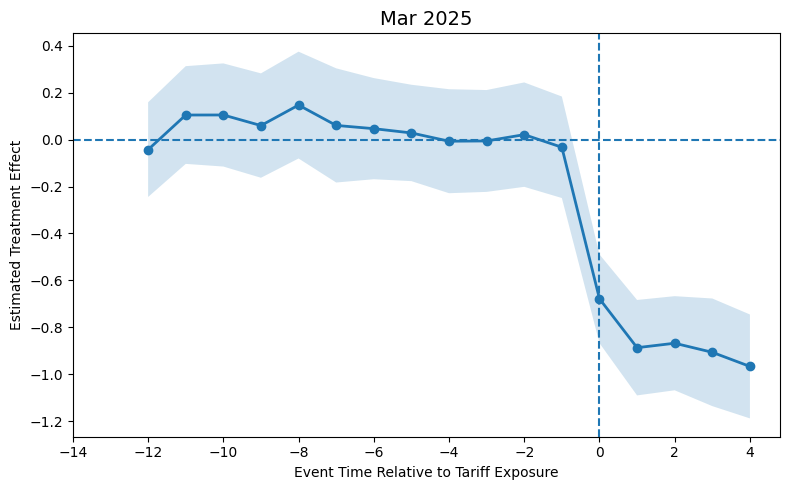

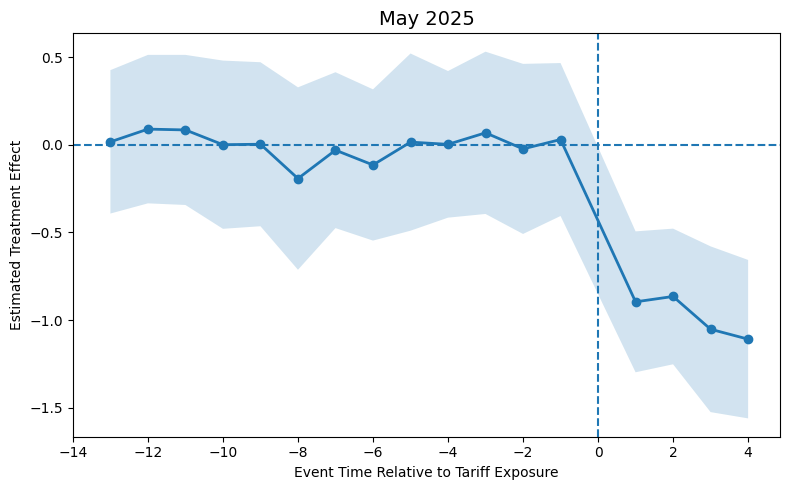

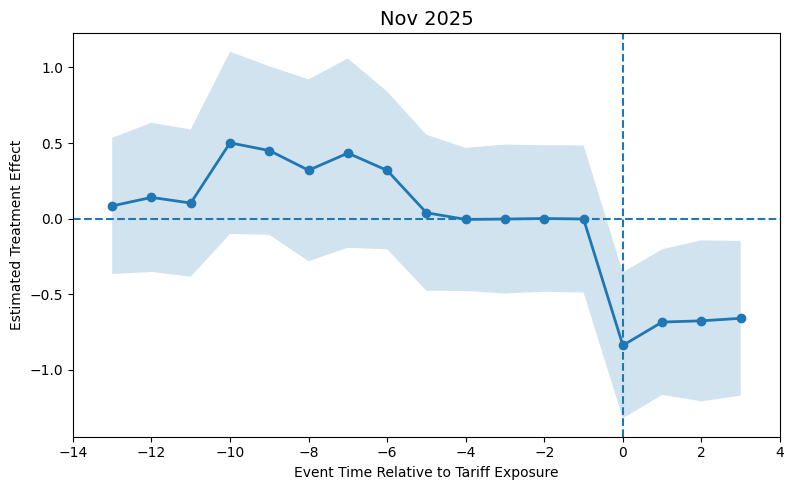

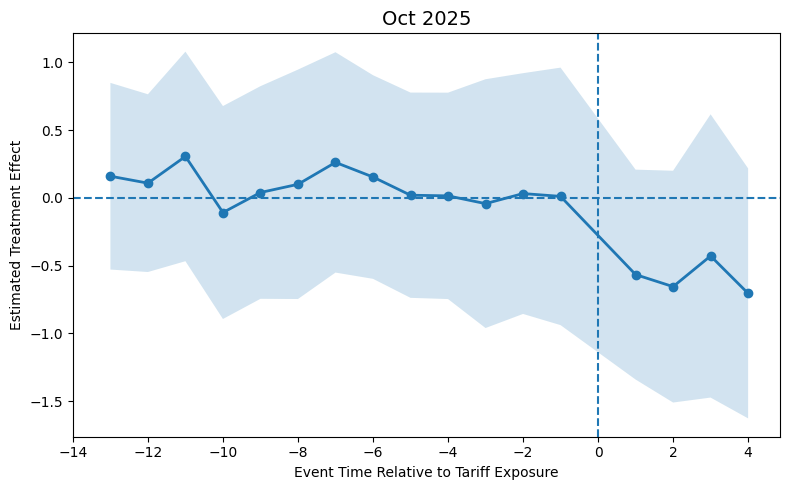

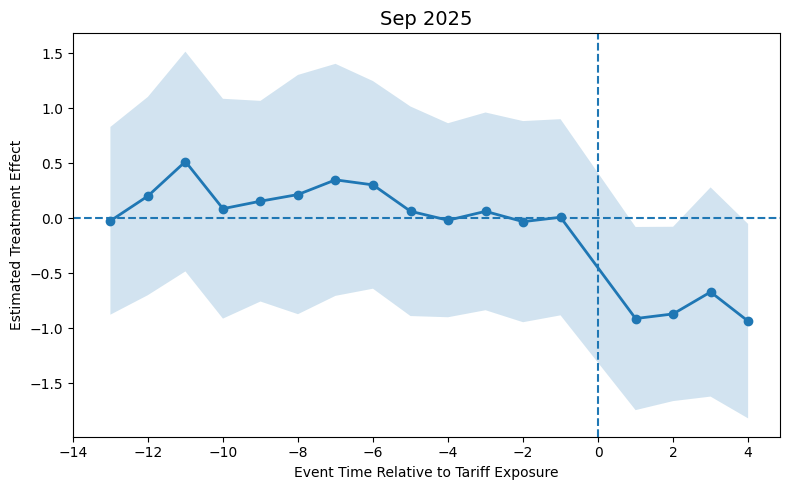

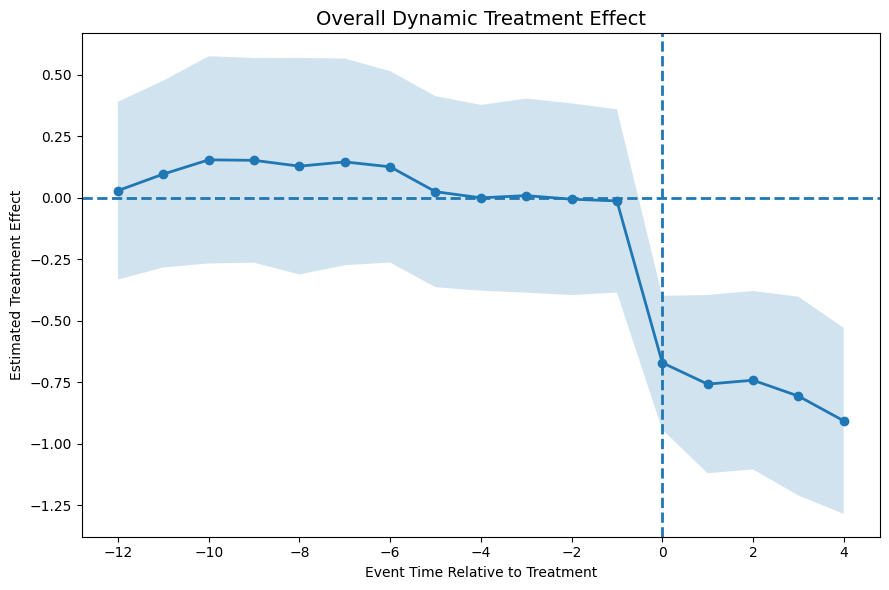

In [123]:
df = pd.read_csv("combine/cohort_dynamic_reindexed_4-10.csv")
plot_event_study(
    df,
    title="Pooled Apr–Oct 2025",
    xlabel="Event Time Relative to Tariff Exposure",
    ylabel="Estimated Treatment Effect"
)

df = pd.read_csv("combine/cohort_dynamic_reindexed.csv")
plot_event_study_by_cohort(
    df,
)

pooled_df = plot_overall_dynamic_effect(
    df,
    min_event_time=-12
)
